#Train-test 나누기

In [ ]:
# YOLOv8-seg (bed polygon) training starter
# - 목적: 180장 라벨링된 베드(segmentation)로 train/val/test split → 학습 → 결과 확인(예시 이미지 저장)
# - 가정: 원본 데이터가 YOLO 포맷으로 정리되어 있음
#   dataset_root/
#     images/   (jpg/png)
#     labels/   (txt)  # YOLO-seg polygon 포맷: cls x1 y1 x2 y2 ... (모두 0~1 정규화)
# - 주의: 현재 라벨 예시에서 class id가 18로 되어 있음. 이 스크립트는 'bed 단일 클래스' 모델을 위해
#         라벨 class를 0으로 remap하여 복사함.

from __future__ import annotations

import os
import random
import shutil
from pathlib import Path
from typing import List, Tuple

# =========================
# 0) 사용자 설정
# =========================
# TODO: 네 환경에 맞게 바꿔
DATASET_ROOT = Path(r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/formodel")  # 여기에 images/, labels/가 있어야 함
OUT_ROOT     = Path(r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/formodel/results")     # split 결과가 생성될 폴더

SEED = 42
TRAIN_RATIO = 0.8
VAL_RATIO   = 0.1
TEST_RATIO  = 0.1

# bed 단일 클래스 학습용 라벨 remap
SOURCE_CLASS_ID = 0
TARGET_CLASS_ID = 0


In [ ]:

# =========================
# 1) train/val/test split
# =========================

def list_image_stems(images_dir: Path, exts=(".jpg", ".jpeg", ".png", ".bmp", ".webp")) -> List[str]:
    stems = []
    for p in images_dir.iterdir():
        if p.is_file() and p.suffix.lower() in exts:
            stems.append(p.stem)
    stems.sort()
    return stems


def ensure_dirs(base: Path):
    for split in ["train", "val", "test"]:
        (base / "images" / split).mkdir(parents=True, exist_ok=True)
        (base / "labels" / split).mkdir(parents=True, exist_ok=True)


def remap_label_file(src_txt: Path, dst_txt: Path, src_id: int = 18, dst_id: int = 0) -> None:
    """YOLO-seg 라벨의 클래스 id만 바꿔서 저장.
    - 한 파일에 여러 객체가 있을 수 있으므로 각 라인 첫 토큰만 확인.
    """
    if not src_txt.exists():
        # 라벨 없으면 빈 파일 생성 (학습 시 background로 취급)
        dst_txt.write_text("", encoding="utf-8")
        return

    out_lines = []
    for line in src_txt.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        # 첫 토큰이 class id
        try:
            cls = int(float(parts[0]))
        except Exception:
            # 이상한 라인은 그대로 통과(안전)
            out_lines.append(line)
            continue

        if cls == src_id:
            parts[0] = str(dst_id)
        # 만약 다른 class가 섞여있다면 그대로 남김(혹은 여기서 제거하고 싶으면 continue 처리)
        out_lines.append(" ".join(parts))

    dst_txt.write_text("\n".join(out_lines) + ("\n" if out_lines else ""), encoding="utf-8")


def split_and_copy(dataset_root: Path, out_root: Path) -> Tuple[List[str], List[str], List[str]]:
    images_dir = dataset_root / "images"
    labels_dir = dataset_root / "labels"

    assert images_dir.exists(), f"images 폴더가 없음: {images_dir}"
    assert labels_dir.exists(), f"labels 폴더가 없음: {labels_dir}"

    stems = list_image_stems(images_dir)
    assert len(stems) > 0, f"이미지가 없음: {images_dir}"

    # 라벨 없는 이미지가 섞여있으면 경고 (학습은 가능하지만 의도 확인 필요)
    missing_labels = [s for s in stems if not (labels_dir / f"{s}.txt").exists()]
    if missing_labels:
        print(f"[WARN] 라벨 없는 이미지가 {len(missing_labels)}장 있음. 예: {missing_labels[:5]}")

    random.seed(SEED)
    random.shuffle(stems)

    n = len(stems)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    # 나머지를 test로
    n_test  = n - n_train - n_val

    train_stems = stems[:n_train]
    val_stems   = stems[n_train:n_train + n_val]
    test_stems  = stems[n_train + n_val:]

    print(f"총 {n}장 → train {len(train_stems)}, val {len(val_stems)}, test {len(test_stems)}")

    # 출력 폴더 초기화(원하면 주석 처리)
    if out_root.exists():
        shutil.rmtree(out_root)
    ensure_dirs(out_root)

    def copy_one(stem: str, split: str):
        # 이미지 복사
        src_img = None
        for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
            cand = images_dir / f"{stem}{ext}"
            if cand.exists():
                src_img = cand
                break
        if src_img is None:
            raise FileNotFoundError(f"이미지를 찾을 수 없음: {stem}")

        dst_img = out_root / "images" / split / src_img.name
        shutil.copy2(src_img, dst_img)

        # 라벨 remap 복사
        src_txt = labels_dir / f"{stem}.txt"
        dst_txt = out_root / "labels" / split / f"{stem}.txt"
        remap_label_file(src_txt, dst_txt, src_id=SOURCE_CLASS_ID, dst_id=TARGET_CLASS_ID)

    for s in train_stems:
        copy_one(s, "train")
    for s in val_stems:
        copy_one(s, "val")
    for s in test_stems:
        copy_one(s, "test")

    return train_stems, val_stems, test_stems


train_stems, val_stems, test_stems = split_and_copy(DATASET_ROOT, OUT_ROOT)


[WARN] 라벨 없는 이미지가 2장 있음. 예: ['bed14_20260308_125537_cam2 (1)', 'bed24_20260317_091746_cam2 (1)']
총 547장 → train 437, val 54, test 56


In [ ]:

# =========================
# 1-1) data.yaml 생성
# =========================

def write_data_yaml(out_root: Path, yaml_path: Path):
    # Ultralytics는 절대경로/상대경로 모두 가능
    yaml_text = f"""# YOLOv8-seg dataset config
path: {out_root.as_posix()}
train: images/train
val: images/val
test: images/test

names:
  0: bed
"""
    yaml_path.write_text(yaml_text, encoding="utf-8")
    print(f"data.yaml 저장: {yaml_path}")

DATA_YAML = OUT_ROOT / "data.yaml"
write_data_yaml(OUT_ROOT, DATA_YAML)


data.yaml 저장: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/formodel/results/data.yaml


#seg-모델학습

In [1]:
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.1 MB/s eta 0:00:00


In [ ]:
# =========================================================
# 3. YOLOv8-seg 학습
# =========================================================

# Colab이면 필요시 먼저 실행
# !pip -q install -U ultralytics

from pathlib import Path
from ultralytics import YOLO
import torch

# torch load 관련 오류가 날 때만 필요할 수 있음
try:
    from ultralytics.nn.tasks import SegmentationModel
    from ultralytics.nn.modules import Conv
    torch.serialization.add_safe_globals([
        SegmentationModel,
        torch.nn.modules.container.Sequential,
        Conv,
    ])
except Exception as e:
    print("[INFO] safe_globals 설정 생략:", e)

# =========================================================
# 추천 설정
# =========================================================
# 2작기 원본이 2592x1944이므로 imgsz=1280부터 권장.
# T4 15GB 기준 yolov8s-seg + imgsz=1280 + batch=4 정도를 먼저 시도.
# OOM 나면 batch=2, 그래도 부족하면 imgsz=960.
# 빠른 테스트만 할 거면 yolov8n-seg.pt 사용.

MODEL_NAME = "yolov8s-seg.pt"   # 빠른 테스트: "yolov8n-seg.pt"
EPOCHS = 120
IMGSZ = 1280
BATCH = 4
DEVICE = 0                      # GPU: 0, CPU: "cpu"

RUN_NAME = "bed_seg_2cycle_v1"

model = YOLO(MODEL_NAME)

results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    seed=SEED,

    # bed는 이미지당 보통 1개 polygon이라 overlap 이슈가 거의 없음
    overlap_mask=False,

    # 550장이라 너무 빨리 멈추지 않게 patience를 조금 여유 있게
    patience=30,

    # 저장 위치
    project=str(OUT_ROOT / "runs"),
    name=RUN_NAME,

    pretrained=True,
    verbose=True,
    plots=True,

    # 데이터가 작으므로 cache=True면 속도는 좋아짐.
    # RAM 부족하면 False로 바꾸세요.
    cache=False,
)

RUN_DIR = Path(results.save_dir)
BEST_PT = RUN_DIR / "weights" / "best.pt"

print("\n[학습 완료]")
print("RUN_DIR:", RUN_DIR)
print("BEST_PT:", BEST_PT)
print("results.png:", RUN_DIR / "results.png")
print("val 예측 예시:", RUN_DIR / "val_batch0_pred.jpg")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/formodel/results/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.

In [ ]:
# =========================================================
# 4. test 이미지 예측 샘플 저장
# =========================================================

import random
import glob
from ultralytics import YOLO
from pathlib import Path

infer_model = YOLO(str(BEST_PT))

test_images = sorted(glob.glob(str(OUT_ROOT / "images" / "test" / "*")))
random.seed(SEED)
sample_imgs = random.sample(test_images, k=min(12, len(test_images)))

PRED_DIR = OUT_ROOT / "pred_samples"
PRED_DIR.mkdir(parents=True, exist_ok=True)

pred_results = infer_model.predict(
    source=sample_imgs,
    imgsz=IMGSZ,
    conf=0.25,
    iou=0.5,
    device=DEVICE,
    save=True,
    project=str(PRED_DIR),
    name=f"{RUN_NAME}_test_samples",
)

print("[예측 샘플 저장 폴더]", PRED_DIR / f"{RUN_NAME}_test_samples")

try:
    from PIL import Image
    from IPython.display import display

    pred_img_paths = sorted((PRED_DIR / f"{RUN_NAME}_test_samples").glob("*.jpg"))
    if pred_img_paths:
        display(Image.open(pred_img_paths[0]))
except Exception as e:
    print("[INFO] 이미지 표시 생략:", e)


Output hidden; open in https://colab.research.google.com to view.

#2작기데이터에대해 적용하기

In [4]:
import os
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm.auto import tqdm
from ultralytics import YOLO
from PIL import Image
import numpy as np

model_path = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/formodel/results/runs/bed_seg_2cycle_v1/weights/best.pt"
filelist_dir = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/1. 원본_핵심/2작기/260306-260402"
savefile_dir = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/0306-0402"

def process_image(img_path):
    # 각 프로세스 독립적으로 모델을 로드하여 충돌 방지
    model = YOLO(model_path)

    # 원본 파일 상대 경로 계산 및 대상 경로 생성
    rel_path = img_path.relative_to(filelist_dir)
    out_path = Path(savefile_dir) / rel_path
    out_path.parent.mkdir(parents=True, exist_ok=True)

    # 추론
    results = model.predict(source=str(img_path), imgsz=1280, conf=0.25, verbose=False)

    # 원본 이미지 로드
    img = Image.open(img_path)
    w, h = img.size

    # 결과 처리 및 Crop
    for r in results:
        if len(r.boxes) > 0:
            # 첫 번째 객체의 바운딩 박스 좌표 추출 (x1, y1, x2, y2)
            box = r.boxes.xyxy[0].cpu().numpy()
            x1, y1, x2, y2 = box

            # 여백 설정
            margin_y = 50
            margin_x_right = 50

            # 가장 왼쪽 끝부터 잘리도록 x1은 0으로 설정
            crop_x1 = 0
            crop_y1 = max(0, y1 - margin_y)
            crop_x2 = min(w, x2 + margin_x_right)
            crop_y2 = min(h, y2 + margin_y)

            # 자르기 (Crop)
            cropped_img = img.crop((crop_x1, crop_y1, crop_x2, crop_y2))
            cropped_img.save(str(out_path))
            break  # 여러 객체가 검출되어도 첫 번째(가장 신뢰도 높은) 베드만 잘라냄
        else:
            # 객체를 찾지 못한 경우 원본 저장 (필요시 제외 가능)
            img.save(str(out_path))
            break

    return str(img_path)

if __name__ == '__main__':
    # 전역 탐색 (확장자 필터링)
    valid_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    all_images = [p for p in Path(filelist_dir).rglob('*') if p.suffix.lower() in valid_exts]

    print(f"총 {len(all_images)}개의 이미지를 찾았습니다.")

    # 4명 동시 수행 (ProcessPoolExecutor)
    with ProcessPoolExecutor(max_workers=4) as executor:
        futures = {executor.submit(process_image, img_path): img_path for img_path in all_images}

        # tqdm으로 남은 시간 표시
        for future in tqdm(as_completed(futures), total=len(all_images), desc="Segmentation & Crop 처리 중"):
            try:
                future.result()
            except Exception as e:
                print(f"오류 발생: {futures[future]} -> {e}")

    print("\n[완료] 모든 크롭 이미지가 저장되었습니다.")

총 1462개의 이미지를 찾았습니다.


Segmentation & Crop 처리 중:   0%|          | 0/1462 [00:00<?, ?it/s]

오류 발생: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/1. 원본_핵심/2작기/260306-260402/260313/bed17_20260313_091412_cam2.jpg -> [Errno 2] No such file or directory: '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/0306-0402/260313/bed17_20260313_091412_cam2.jpg'
오류 발생: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/1. 원본_핵심/2작기/260306-260402/260313/bed85_20260313_112544_cam2.jpg -> [Errno 2] No such file or directory: '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/0306-0402/260313/bed85_20260313_112544_cam2.jpg'

[완료] 모든 크롭 이미지가 저장되었습니다.


모델 로딩 중...
총 5장에 대해 빨간 박스 기준 적용 시작...
저장 완료: redbox_bed41_20260402_181440_cam2.jpg (Height 313px -> 270px)


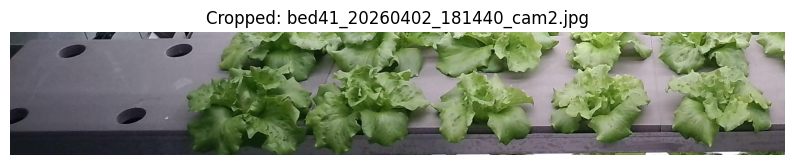

저장 완료: redbox_bed89_20260402_194843_cam2.jpg (Height 296px -> 255px)


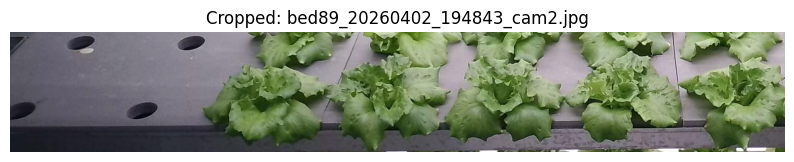

저장 완료: redbox_bed30_20260402_140400_cam2.jpg (Height 307px -> 265px)


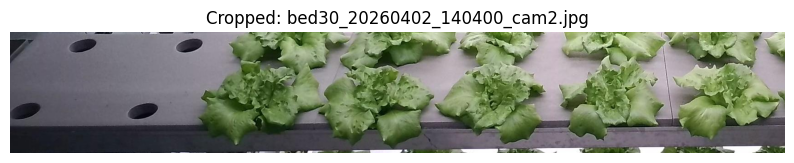

저장 완료: redbox_bed87_20260402_165544_cam2.jpg (Height 316px -> 272px)


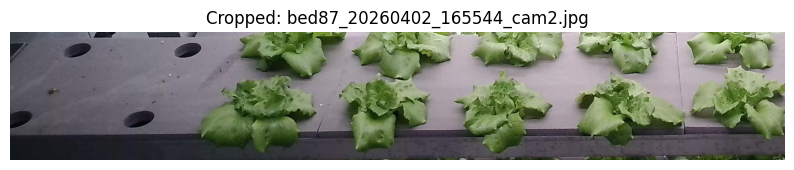

저장 완료: redbox_bed83_20260402_164756_cam2.jpg (Height 312px -> 269px)


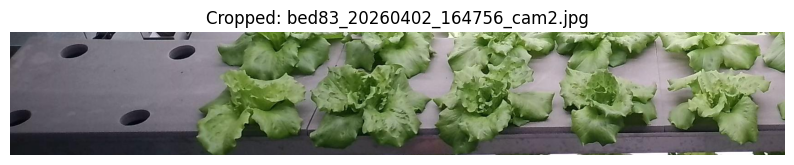


테스트 완료! /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/formodel/example 폴더에서 결과를 확인하세요.


In [10]:
import os
import cv2
import torch
import random
from pathlib import Path
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ================================================================= #
# 1. 경로 및 파라미터 설정
# ================================================================= #
MODEL_PATH = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/formodel/results/runs/bed_seg_2cycle_v1/weights/best.pt"

# 테스트할 폴더 경로
TEST_DIR = Path(r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/0306-0402/260402")

# 폴더 내 이미지 전역 탐색 후 랜덤 5장 선택
valid_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
all_images = [str(p) for p in TEST_DIR.rglob('*') if p.suffix.lower() in valid_exts]
TEST_IMAGES = random.sample(all_images, min(5, len(all_images))) if all_images else []

SAVE_DIR = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/formodel/example"
os.makedirs(SAVE_DIR, exist_ok=True)

# 빨간 박스 비율 (사용자님의 '감'을 수치화)
TOP_TRIM_RATIO = 0.14    # 상단에서 베드 높이의 18%를 잘라냄 (뒷면 상추 제거용)
BOTTOM_TRIM_RATIO = 0.02  # 하단은 프레임에 딱 맞춤 (아랫줄 상추 방어)

# ================================================================= #
# 2. 이미지 처리 함수
# ================================================================= #

def apply_red_box_crop(img_path, model):
    img = cv2.imread(img_path)
    if img is None: return

    h_orig, w_orig = img.shape[:2]

    # 1. YOLO 추론
    results = model.predict(img_path, conf=0.25, device=0, verbose=False)

    if not results[0].boxes:
        print(f"검출 실패: {os.path.basename(img_path)}")
        return

    # 2. 베드 영역 좌표 확보 (Bounding Box 기준)
    # 여러 개 검출 시 가장 큰 박스 혹은 첫 번째 박스 선택
    box = results[0].boxes.xyxy[0].cpu().numpy()
    x1, y1, x2, y2 = map(int, box)

    bed_h = y2 - y1 # 검출된 베드의 순수 높이

    # 3. 사용자 요청 '빨간 박스' 계산
    # 상단: y1에서 높이의 18%만큼 내려옴
    new_y1 = int(y1 + (bed_h * TOP_TRIM_RATIO))
    # 하단: y2 그대로 유지 (프레임 라인)
    new_y2 = y2
    # 좌우: 왼쪽 끝은 0, 오른쪽은 베드 끝 + 약간의 마진(50px)
    new_x1 = 0
    new_x2 = min(w_orig, x2 + 50)

    # 4. 크롭 및 저장
    cropped = img[new_y1:new_y2, new_x1:new_x2]

    save_path = os.path.join(SAVE_DIR, "redbox_" + os.path.basename(img_path))
    cv2.imwrite(save_path, cropped)
    print(f"저장 완료: {os.path.basename(save_path)} (Height {bed_h}px -> {new_y2-new_y1}px)")

    # 5. 화면에 표기 (matplotlib 이용)
    plt.figure(figsize=(10, 5))
    plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
    plt.title(f"Cropped: {os.path.basename(img_path)}")
    plt.axis('off')
    plt.show()

# ================================================================= #
# 3. 실행
# ================================================================= #
if __name__ == "__main__":
    print("모델 로딩 중...")
    model = YOLO(MODEL_PATH)

    if not TEST_IMAGES:
        print("해당 폴더에서 이미지를 찾을 수 없습니다.")
    else:
        print(f"총 {len(TEST_IMAGES)}장에 대해 빨간 박스 기준 적용 시작...")
        for path in TEST_IMAGES:
            apply_red_box_crop(path, model)

        print(f"\n테스트 완료! {SAVE_DIR} 폴더에서 결과를 확인하세요.")


#다시 1485장에 대하여

In [14]:
import os
from pathlib import Path
from tqdm.auto import tqdm
from ultralytics import YOLO
from PIL import Image
import numpy as np

# ================================================================= #
# 1. 경로 및 파라미터 설정
# ================================================================= #
model_path = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/formodel/results/runs/bed_seg_2cycle_v1/weights/best.pt"
filelist_dir = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/1. 원본_핵심/2작기/260306-260402"
savefile_dir = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/0306-0402_2"

# [핵심] 절단 비율 설정
TOP_TRIM_RATIO = 0.10    # 상단 14% (뒷면 상추 노이즈 제거용)
BOTTOM_TRIM_RATIO = 0.02 # 하단 2% (아랫줄 상추 혼입 방지용)
RIGHT_MARGIN = 50        # 우측 여유분 (보정 원 보호용)

# ================================================================= #
# 2. 실행부 (단일 프로세스, 모델 1회 로드)
# ================================================================= #
if __name__ == '__main__':
    # 확장자 필터링하여 이미지 목록 확보
    valid_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    all_images = [p for p in Path(filelist_dir).rglob('*') if p.suffix.lower() in valid_exts]

    print(f"[{len(all_images)}개 이미지] 분석 및 빨간 박스 크롭을 시작합니다.")
    print(f"설정: 상단 {TOP_TRIM_RATIO*100}% 절단 / 하단 {BOTTOM_TRIM_RATIO*100}% 절단")

    # GPU 메모리 이슈를 방지하기 위해 모델을 한 번만 로드
    model = YOLO(model_path)

    # tqdm으로 남은 시간 및 진행률 표시
    for img_path in tqdm(all_images, desc="상추 베드 ROI 추출 중"):
        try:
            rel_path = img_path.relative_to(filelist_dir)
            out_path = Path(savefile_dir) / rel_path
            out_path.parent.mkdir(parents=True, exist_ok=True)

            # 1. 추론 (고해상도 imgsz=1280)
            results = model.predict(source=str(img_path), imgsz=1280, conf=0.25, verbose=False)

            # 원본 이미지 로드
            img = Image.open(img_path)
            w, h = img.size

            if len(results[0].boxes) > 0:
                # 첫 번째 객체의 좌표 추출
                box = results[0].boxes.xyxy[0].cpu().numpy()
                x1, y1, x2, y2 = box

                # 베드의 순수 높이 계산
                bed_h = y2 - y1

                # [빨간 박스 로직 적용]
                crop_x1 = 0
                crop_y1 = max(0, y1 + (bed_h * TOP_TRIM_RATIO))
                crop_x2 = min(w, x2 + RIGHT_MARGIN)
                crop_y2 = min(h, y2 - (bed_h * BOTTOM_TRIM_RATIO))

                # 자르기 (Crop) 및 저장
                cropped_img = img.crop((crop_x1, crop_y1, crop_x2, crop_y2))
                cropped_img.save(str(out_path), quality=95) # 품질 유지
            else:
                # 검출 실패 시 원본 저장
                img.save(str(out_path))

        except Exception as e:
            print(f"Error {img_path.name}: {str(e)}")

    print("\n" + "="*50)
    print("전수 조사 및 크롭 완료!")
    print(f"결과 저장 경로: {savefile_dir}")
    print("="*50)


[1462개 이미지] 분석 및 빨간 박스 크롭을 시작합니다.
설정: 상단 10.0% 절단 / 하단 2.0% 절단


상추 베드 ROI 추출 중:   0%|          | 0/1462 [00:00<?, ?it/s]


전수 조사 및 크롭 완료!
결과 저장 경로: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/0306-0402_2
